# 🔬 Experiment Set 6 — Partial Specification Matching
## Can the system still retrieve correct SKUs with incomplete RFP specs?

---

## Dataset Strategy

This experiment uses **synthetically generated** partial specs derived from the clean dataset.
We create three progressively stripped levels directly in-notebook:

| Level | Tokens Kept | Example | Source |
|---|---|---|---|
| **Full** | All ~8 tokens | `FRLS 1.1kV 4C 0.75sqmm Cu PVC armoured cable as per IEC 60502-1` | `rfp_specs_7000.csv` |
| **Level 1 — Mild** | 4 tokens | `FRLS 1.1kV 0.75sqmm PVC cable` | Generated in-notebook |
| **Level 2 — Moderate** | 2 tokens | `FRLS 1.1kV cable` | Generated in-notebook |
| **Level 3 — Severe** | 1 token | `FRLS cable` | Generated in-notebook |

**Why NOT use existing noisy datasets:**

| Dataset | Why NOT used |
|---|---|
| Missing Specs (Variant 5) | Drops 1-4 random tokens, leaving 3-7 tokens — covers Level 1 only |
| All other variants | Test different failure modes (noise, length, units) — not completeness |
| **Synthetic partial specs** | **Full control over completeness level — enables clean 4-point degradation curve** |

## Why This is Fundamentally Different From Experiment 3

- **Exp 3 (Missing Specs)**: Removes 1-4 random token types from 8-token specs → 3-7 tokens remain
- **Exp 6 (Partial Spec)**: Systematically reduces specs to 4, 2, or 1 token → tests extreme incompleteness
- Exp 3 tests *robustness to accidental omission*; Exp 6 tests *minimum information needed for correct retrieval*

## Key Research Question
At what level of completeness does each model break down?
The Hybrid's structured columns are ALWAYS intact — the partial text only affects
the 30%-weighted semantic component. SBERT's entire signal lives in the text.

## Metrics
1. **Accuracy Drop % per level** — Top-1 degradation at each completeness level
2. **Minimum Viable Spec (MVS)** — the completeness level at which Top-1 drops below 50% of clean
3. **Token Contribution Analysis** — which single token, when present alone, gives the best retrieval?
4. **Full IR metrics** — Top-1, Top-5, MRR, NDCG@5 across all four completeness levels
5. **Structural field retention advantage** — how much does the Hybrid's structural score compensate for text loss?

In [1]:
# CELL 1 — INSTALL
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [2]:
# CELL 2 — IMPORTS
import os, json, re, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Dict, Optional, Tuple, List
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
EXP_DIR      = 'exp6_partial_spec'
os.makedirs(EXP_DIR, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


In [3]:
# CELL 3 — LOAD ARTIFACTS + CLEAN DATASET
# Upload to Colab:
#   obj1_model_artifacts/   (from Objective 1)
#   rfp_specs_7000.csv      (clean — all levels generated from this)
#   product_catalog.csv

cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

df_clean = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
for df in [df_clean, product_df]:
    df.columns = df.columns.str.strip()

gt_lookup = (
    rfp_gt_df.dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']

print(f'Product catalog : {product_df.shape}')
print(f'Clean RFP specs : {df_clean.shape}')
print(f'GT entries      : {len(gt_lookup)}')
print(f'K               : {K}')
print(f'Hybrid weights  : {cfg["hybrid_weights"]}')
print('\nObj 1 Baseline:')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog : (200, 16)
Clean RFP specs : (7000, 17)
GT entries      : 7000
K               : 5
Hybrid weights  : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}

Obj 1 Baseline:
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [4]:
# CELL 4 — GENERATE PARTIAL SPEC DATASETS
# Systematically strip spec_text_raw down to 4, 2, 1 token types
# Structural columns ALWAYS remain unchanged (key design)

TOKEN_PATTERNS = {
    'voltage':    r'\b\d+(?:\.\d+)?(?:kV|V)\b',
    'size_sqmm':  r'\b\d+(?:\.\d+)?\s*sqmm\b',
    'core_count': r'\b\d+C\b',
    'conductor':  r'\b(Cu|Al)\b',
    'insulation': r'\b(XLPE|PVC|EPR)\b',
    'fire_rating':r'\b(FRLS|FR|LSZH|ZH|Fire Survival)\b',
    'armouring':  r'\b(armoured)\b',
    'standard':   r'\bas per\s+[\w\s\-]+\d[\w\-]*',
}

def count_tokens_present(text):
    return sum(1 for k, pat in TOKEN_PATTERNS.items() if re.findall(pat, str(text)))

def strip_to_n_types(text, n_keep, seed=42):
    rng = random.Random(seed)
    present = [(k, pat) for k, pat in TOKEN_PATTERNS.items() if re.findall(pat, str(text))]
    if len(present) <= n_keep:
        return str(text)
    keep_keys = set(k for k, _ in rng.sample(present, n_keep))
    result = str(text)
    for k, pat in TOKEN_PATTERNS.items():
        if k not in keep_keys:
            result = re.sub(pat, '', result)
    result = re.sub(r'  +', ' ', result).strip()
    # Ensure 'cable' word remains
    if 'cable' not in result:
        result = result + ' cable'
    return result

# Per-row seed varies by row index for diversity
def make_partial_dataset(n_keep):
    df = df_clean.copy()
    df['spec_text_raw'] = [
        strip_to_n_types(row['spec_text_raw'], n_keep, seed=42+i)
        for i, (_, row) in enumerate(df.iterrows())
    ]
    return df

df_level1 = make_partial_dataset(4)   # 4 token types: FRLS 1.1kV 0.75sqmm PVC cable
df_level2 = make_partial_dataset(2)   # 2 token types: FRLS 1.1kV cable
df_level3 = make_partial_dataset(1)   # 1 token type:  FRLS cable

# Word count stats per level
for name, df in [('Full',df_clean),('Level1',df_level1),('Level2',df_level2),('Level3',df_level3)]:
    wc = df['spec_text_raw'].str.split().str.len()
    tc = df['spec_text_raw'].apply(count_tokens_present)
    print(f'{name:8s}: avg_words={wc.mean():.1f}  avg_token_types={tc.mean():.1f}')

print('\nSample partial specs:')
for i in [0, 3, 10, 50]:
    print(f'  FULL   : {df_clean.loc[i,"spec_text_raw"]}')
    print(f'  LEVEL1 : {df_level1.loc[i,"spec_text_raw"]}')
    print(f'  LEVEL2 : {df_level2.loc[i,"spec_text_raw"]}')
    print(f'  LEVEL3 : {df_level3.loc[i,"spec_text_raw"]}')
    print()

Full    : avg_words=12.9  avg_token_types=7.8
Level1  : avg_words=7.2  avg_token_types=4.0
Level2  : avg_words=4.2  avg_token_types=2.0
Level3  : avg_words=2.6  avg_token_types=1.0

Sample partial specs:
  FULL   : FRLS 1.1kV 4C 0.75 sqmm Cu PVC armoured cable as per IEC 60502-1
  LEVEL1 : FRLS 1.1kV 4C 0.75 sqmm cable
  LEVEL2 : 1.1kV 0.75 sqmm cable
  LEVEL3 : 0.75 sqmm cable

  FULL   : FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  LEVEL1 : 1C Cu EPR armoured cable
  LEVEL2 : Cu EPR cable
  LEVEL3 : EPR cable

  FULL   : FR 300V 24C 2.5 sqmm Cu XLPE armoured cable as per BS 5308-1
  LEVEL1 : FR 300V XLPE cable as per BS 5308-1
  LEVEL2 : 300V XLPE cable
  LEVEL3 : XLPE cable

  FULL   : LSZH 500V 4C 4 sqmm Cu XLPE armoured cable as per IS 1554
  LEVEL1 : LSZH XLPE armoured cable as per IS 1554
  LEVEL2 : XLPE armoured cable
  LEVEL3 : armoured cable



In [5]:
# CELL 5 — SHARED SCORING FUNCTIONS
_SIZE_LADDER = [0.5,0.75,1.0,1.5,2.5,4.0,6.0,10.0,16.0,25.0,35.0,50.0,70.0,95.0,
                120.0,150.0,185.0,240.0,300.0,400.0,500.0,630.0,800.0,1000.0]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET: val = min(_SIZE_LADDER, key=lambda x: abs(x-val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0: n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER)-1: n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    score = total = 0.0
    for field in cfg['exact_fields']:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score/total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0; evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank = int(pos[0]) + 1; evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk += 1; prec_sum += 1.0/K; ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}
    ideal = 1.0/np.log2(2)
    return {'Top-1 Acc': top1/evaluated, 'Top-5 Acc': topk/evaluated,
            'Recall@5': topk/evaluated, 'MRR': mrr_sum/evaluated,
            'Precision@5': prec_sum/evaluated, 'NDCG@5': (ndcg_sum/evaluated)/ideal}

def build_groups(mdf):
    groups = {}
    for rfp_id, grp in mdf.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [8]:
# CELL 6 — ENCODE ALL FOUR LEVELS
all_texts = {
    'Full':   df_clean['spec_text_raw'].astype(str).tolist(),
    'Level1': df_level1['spec_text_raw'].astype(str).tolist(),
    'Level2': df_level2['spec_text_raw'].astype(str).tolist(),
    'Level3': df_level3['spec_text_raw'].astype(str).tolist(),
}
prod_texts = product_df['product_name'].astype(str).tolist()

print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')
emb_mpnet = {}
for name, texts in all_texts.items():
    emb_mpnet[name] = mpnet.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)
    print(f'  MPNet [{name}] done')
sem_mpnet = {k: (v @ product_emb.T).astype(np.float32) for k, v in emb_mpnet.items()}
print(f'MPNet total: {time.time()-t0:.1f}s')

print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')
prod_emb_mini = minilm.encode(prod_texts, batch_size=128, normalize_embeddings=True)
emb_mini = {}
for name, texts in all_texts.items():
    emb_mini[name] = minilm.encode(texts, batch_size=128, normalize_embeddings=True, show_progress_bar=False)
    print(f'  MiniLM [{name}] done')
sem_mini = {k: (v @ prod_emb_mini.T).astype(np.float32) for k, v in emb_mini.items()}
print(f'MiniLM total: {time.time()-t1:.1f}s')

print('\nComputing TF-IDF...')
all_combined = prod_texts.copy()
for texts in all_texts.values(): all_combined += texts
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(all_combined)
prod_tfidf = tfidf.transform(prod_texts)
tfidf_mat = {k: (tfidf.transform(v) @ prod_tfidf.T).toarray().astype(np.float32)
             for k, v in all_texts.items()}
print('TF-IDF done.')

print('Computing BM25...')
t2 = time.time()
bm25_model = BM25Okapi([t.lower().split() for t in prod_texts])
def bm25_mat(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        sc = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = sc.max()
        mat[i] = sc/mx if mx > 0 else sc
    return mat
bm25_mats = {k: bm25_mat(v) for k, v in all_texts.items()}
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  MPNet [Full] done
  MPNet [Level1] done
  MPNet [Level2] done
  MPNet [Level3] done
MPNet total: 29.5s

Loading MiniLM...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  MiniLM [Full] done
  MiniLM [Level1] done
  MiniLM [Level2] done
  MiniLM [Level3] done
MiniLM total: 7.6s

Computing TF-IDF...
TF-IDF done.
Computing BM25...
BM25 done in 9.0s


In [9]:
# CELL 7 — BUILD MATCH MATRICES FOR ALL FOUR LEVELS
# Structured + standards scores IDENTICAL (structural cols unchanged)
print('Computing structured + standards scores...')
t0 = time.time()
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)
for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i,j] = structured_score(rfp_row, sku_row)
        std_mat[i,j]    = standards_score(rfp_row, sku_row)
print(f'Done in {time.time()-t0:.1f}s')

W  = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(level_name, rfp_src):
    rows = []
    rfp_ids = rfp_src['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    sm = sem_mpnet[level_name]
    mm = sem_mini[level_name]
    tm = tfidf_mat[level_name]
    bm = bm25_mats[level_name]
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sm[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], struct_mat[i,j], float(sm[i,j]),
                         float(mm[i,j]), float(tm[i,j]), float(bm[i,j]),
                         std_mat[i,j], hybrid))
    mdf = pd.DataFrame(rows, columns=[
        'RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'])
    print(f'  [{level_name}] {mdf.shape}')
    return mdf

level_dfs   = {}
level_src   = {'Full': df_clean, 'Level1': df_level1, 'Level2': df_level2, 'Level3': df_level3}
for name, src in level_src.items():
    print(f'Building [{name}]...')
    level_dfs[name] = build_match_df(name, src)

groups = {name: build_groups(mdf) for name, mdf in level_dfs.items()}
print('✅ All match groups built.')

Computing structured + standards scores...
Done in 126.8s
Building [Full]...
  [Full] (1400000, 9)
Building [Level1]...
  [Level1] (1400000, 9)
Building [Level2]...
  [Level2] (1400000, 9)
Building [Level3]...
  [Level3] (1400000, 9)
✅ All match groups built.


In [10]:
# CELL 8 — METRIC 1: IR METRICS ACROSS ALL FOUR COMPLETENESS LEVELS
all_model_configs = [
    ('Random Baseline',        'random',    None),
    ('TF-IDF + Cosine',        'tfidf',     None),
    ('BM25 (Okapi)',           'bm25',      None),
    ('SBERT MiniLM-L6',        'minilm',    None),
    ('SBERT MPNet (sem-only)', 'semantic',  None),
    ('Exact Structured',       'structured',None),
    ('Hybrid (Ours)',          'hybrid',    None),
]

rng = np.random.default_rng(42)
def add_random(grps):
    rg = {}
    for k, v in grps.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rgroups = {name: add_random(grp) for name, grp in groups.items()}

level_labels = {'Full':'Full (8 tokens)', 'Level1':'Level 1 (4 tokens)',
                'Level2':'Level 2 (2 tokens)', 'Level3':'Level 3 (1 token)'}

ir_rows = []
for label, score_key, weights in all_model_configs:
    row = {'Model': label}
    base_t1 = None
    for level in ['Full','Level1','Level2','Level3']:
        g = rgroups[level] if score_key == 'random' else groups[level]
        m = compute_metrics(g, gt_lookup, score_key=score_key, weights=weights, K=K)
        row[f'{level}_Top1']  = m['Top-1 Acc']
        row[f'{level}_Top5']  = m['Top-5 Acc']
        row[f'{level}_MRR']   = m['MRR']
        row[f'{level}_NDCG']  = m['NDCG@5']
        if base_t1 is None: base_t1 = m['Top-1 Acc']
        row[f'{level}_Drop%'] = (m['Top-1 Acc'] - base_t1) / base_t1 * 100 if base_t1 > 0 else 0
    ir_rows.append(row)

ir_df = pd.DataFrame(ir_rows)

print('\n' + '='*115)
print('  Partial Specification Matching: Top-1 Accuracy Across Completeness Levels')
print('='*115)
print(ir_df[['Model','Full_Top1','Level1_Top1','Level1_Drop%','Level2_Top1','Level2_Drop%','Level3_Top1','Level3_Drop%']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n  MRR:')
print(ir_df[['Model','Full_MRR','Level1_MRR','Level2_MRR','Level3_MRR']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n  Top-5 Accuracy:')
print(ir_df[['Model','Full_Top5','Level1_Top5','Level2_Top5','Level3_Top5']]
      .to_markdown(index=False, floatfmt='.4f'))


  Partial Specification Matching: Top-1 Accuracy Across Completeness Levels
| Model                  |   Full_Top1 |   Level1_Top1 |   Level1_Drop% |   Level2_Top1 |   Level2_Drop% |   Level3_Top1 |   Level3_Drop% |
|:-----------------------|------------:|--------------:|---------------:|--------------:|---------------:|--------------:|---------------:|
| Random Baseline        |      0.0046 |        0.0054 |        18.7500 |        0.0043 |        -6.2500 |        0.0063 |        37.5000 |
| TF-IDF + Cosine        |      0.1343 |        0.0559 |       -58.4043 |        0.0304 |       -77.3404 |        0.0186 |       -86.1702 |
| BM25 (Okapi)           |      0.0559 |        0.0417 |       -25.3197 |        0.0221 |       -60.3581 |        0.0123 |       -78.0051 |
| SBERT MiniLM-L6        |      0.1326 |        0.0579 |       -56.3578 |        0.0280 |       -78.8793 |        0.0081 |       -93.8578 |
| SBERT MPNet (sem-only) |      0.1653 |        0.0916 |       -44.5981 |        0.

In [11]:
# CELL 9 — METRIC 2: MINIMUM VIABLE SPEC (MVS)
# The level at which Top-1 drops below 50% of clean performance
# AND per-level retention rates

print('=== Retention Rates & Minimum Viable Spec (MVS) ===')
print()

for _, row in ir_df.iterrows():
    base = row['Full_Top1']
    if base == 0: continue
    rets = {
        'Level1': row['Level1_Top1']/base*100,
        'Level2': row['Level2_Top1']/base*100,
        'Level3': row['Level3_Top1']/base*100,
    }
    # MVS: first level where retention drops below 50%
    mvs = 'Full (never drops below 50%)'
    for level, ret in rets.items():
        if ret < 50.0:
            mvs = level
            break
    print(f'  {row.Model:35s}  L1={rets["Level1"]:5.1f}%  L2={rets["Level2"]:5.1f}%  L3={rets["Level3"]:5.1f}%  MVS={mvs}')

=== Retention Rates & Minimum Viable Spec (MVS) ===

  Random Baseline                      L1=118.7%  L2= 93.8%  L3=137.5%  MVS=Full (never drops below 50%)
  TF-IDF + Cosine                      L1= 41.6%  L2= 22.7%  L3= 13.8%  MVS=Level1
  BM25 (Okapi)                         L1= 74.7%  L2= 39.6%  L3= 22.0%  MVS=Level2
  SBERT MiniLM-L6                      L1= 43.6%  L2= 21.1%  L3=  6.1%  MVS=Level1
  SBERT MPNet (sem-only)               L1= 55.4%  L2= 22.6%  L3=  8.4%  MVS=Level2
  Exact Structured                     L1=100.0%  L2=100.0%  L3=100.0%  MVS=Full (never drops below 50%)
  Hybrid (Ours)                        L1= 85.2%  L2= 68.4%  L3= 58.7%  MVS=Full (never drops below 50%)


In [12]:
# CELL 10 — METRIC 3: SINGLE-TOKEN CONTRIBUTION ANALYSIS
# For Level 3 (1 token), which single token type gives the best retrieval?
# This tells us: what is the MOST INFORMATIVE single field in a cable RFP?

TOKEN_SINGLE = {
    'Voltage only':     ('voltage',   r'\b\d+(?:\.\d+)?(?:kV|V)\b'),
    'Fire rating only': ('fire_rating',r'\b(FRLS|FR|LSZH|ZH|Fire Survival)\b'),
    'Insulation only':  ('insulation', r'\b(XLPE|PVC|EPR)\b'),
    'Conductor only':   ('conductor',  r'\b(Cu|Al)\b'),
    'Core count only':  ('core_count', r'\b\d+C\b'),
    'Size only':        ('size_sqmm',  r'\b\d+(?:\.\d+)?\s*sqmm\b'),
    'Armouring only':   ('armouring',  r'\b(armoured)\b'),
    'Standard only':    ('standard',   r'\bas per\s+[\w\s\-]+\d[\w\-]*'),
}

def make_single_token_dataset(token_key, keep_pat):
    result_texts = []
    for i, row in df_clean.iterrows():
        text = str(row['spec_text_raw'])
        # Keep only this token type, drop all others
        remaining = str(row['spec_text_raw'])
        for k, (tk, pat) in TOKEN_SINGLE.items():
            if tk != token_key:
                remaining = re.sub(pat, '', remaining)
        remaining = re.sub(r'  +', ' ', remaining).strip()
        if 'cable' not in remaining.lower():
            remaining = remaining + ' cable'
        result_texts.append(remaining)
    return result_texts

single_token_rows = []
for token_label, (token_key, keep_pat) in TOKEN_SINGLE.items():
    texts = make_single_token_dataset(token_key, keep_pat)
    # Encode with MPNet
    emb = mpnet.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)
    sem = (emb @ product_emb.T).astype(np.float32)
    # Build hybrid match
    rows = []
    rfp_ids = df_clean['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], float(sem[i,j]), hybrid))
    mdf = pd.DataFrame(rows, columns=['RFP_ID','SKU_ID','Semantic_Score','Hybrid_Score'])
    grp = {}
    for rfp_id, g in mdf.groupby('RFP_ID', sort=False):
        grp[rfp_id] = {'sku_id': g['SKU_ID'].to_numpy(),
                       'semantic': g['Semantic_Score'].to_numpy(np.float32),
                       'hybrid':   g['Hybrid_Score'].to_numpy(np.float32),
                       'structured': struct_mat[df_clean[df_clean['rfp_id']==rfp_id].index[0]],
                       'standards':  std_mat[df_clean[df_clean['rfp_id']==rfp_id].index[0]]}
    ms = compute_metrics(grp, gt_lookup, score_key='semantic', K=K)
    mh = compute_metrics(grp, gt_lookup, score_key='hybrid',   K=K)
    single_token_rows.append({
        'Token Type':    token_label,
        'SBERT Top-1':   ms['Top-1 Acc'],
        'SBERT MRR':     ms['MRR'],
        'Hybrid Top-1':  mh['Top-1 Acc'],
        'Hybrid MRR':    mh['MRR'],
    })
    print(f'  {token_label:20s}: SBERT Top-1={ms["Top-1 Acc"]:.4f}  Hybrid Top-1={mh["Top-1 Acc"]:.4f}')

st_df = pd.DataFrame(single_token_rows).sort_values('Hybrid Top-1', ascending=False)
print('\n  Full single-token ranking:')
print(st_df.to_markdown(index=False, floatfmt='.4f'))

  Voltage only        : SBERT Top-1=0.0523  Hybrid Top-1=0.1533
  Fire rating only    : SBERT Top-1=0.0176  Hybrid Top-1=0.0973
  Insulation only     : SBERT Top-1=0.0011  Hybrid Top-1=0.0957
  Conductor only      : SBERT Top-1=0.0027  Hybrid Top-1=0.0931
  Core count only     : SBERT Top-1=0.0221  Hybrid Top-1=0.0950
  Size only           : SBERT Top-1=0.0131  Hybrid Top-1=0.1033
  Armouring only      : SBERT Top-1=0.0000  Hybrid Top-1=0.0976
  Standard only       : SBERT Top-1=0.0030  Hybrid Top-1=0.1109

  Full single-token ranking:
| Token Type       |   SBERT Top-1 |   SBERT MRR |   Hybrid Top-1 |   Hybrid MRR |
|:-----------------|--------------:|------------:|---------------:|-------------:|
| Voltage only     |        0.0523 |      0.1589 |         0.1533 |       0.2824 |
| Standard only    |        0.0030 |      0.0518 |         0.1109 |       0.2333 |
| Size only        |        0.0131 |      0.0507 |         0.1033 |       0.2210 |
| Armouring only   |        0.0000 |      0

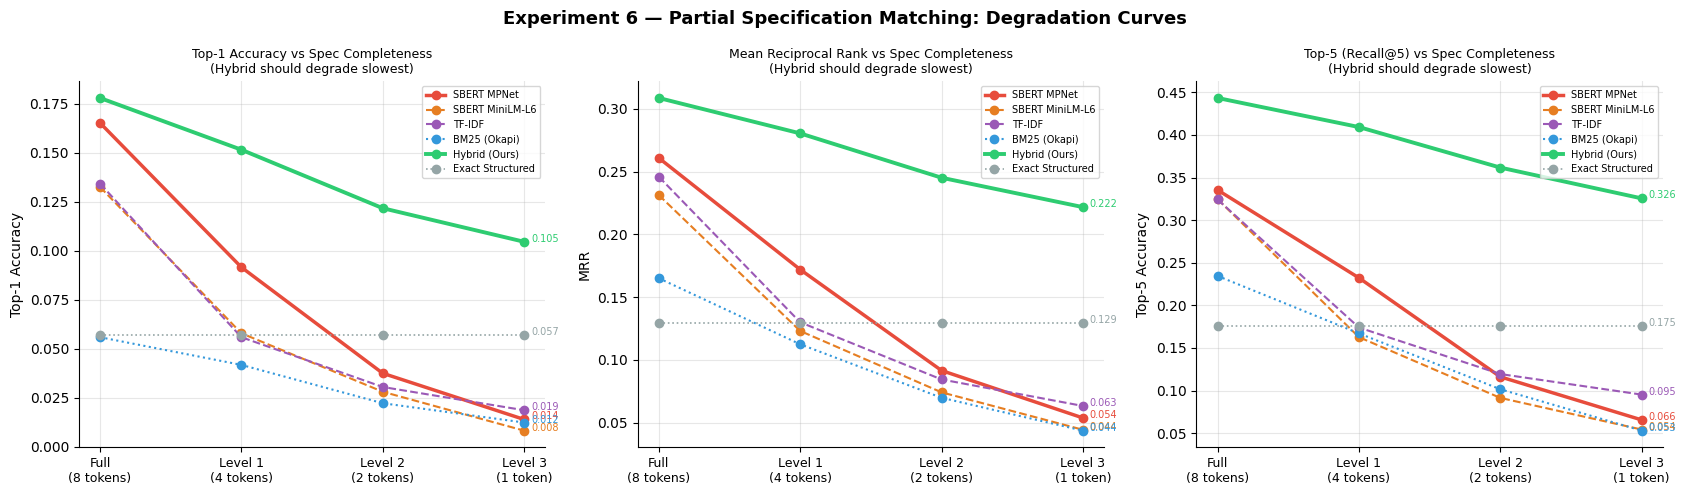

✅ Saved exp6_degradation_curves.png


In [13]:
# CELL 11 — VISUALISATION 1: 4-LEVEL DEGRADATION CURVES
focus_models = [
    ('SBERT MPNet (sem-only)', '#e74c3c', '-',  2.5),
    ('SBERT MiniLM-L6',        '#e67e22', '--', 1.5),
    ('TF-IDF + Cosine',        '#9b59b6', '--', 1.5),
    ('BM25 (Okapi)',           '#3498db', ':',  1.5),
    ('Hybrid (Ours)',          '#2ecc71', '-',  2.8),
    ('Exact Structured',       '#95a5a6', ':',  1.2),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x_pos    = [0, 1, 2, 3]
x_labels = ['Full\n(8 tokens)', 'Level 1\n(4 tokens)', 'Level 2\n(2 tokens)', 'Level 3\n(1 token)']

for ax, (col_prefix, ylabel, title) in zip(axes, [
    ('Top1', 'Top-1 Accuracy', 'Top-1 Accuracy'),
    ('MRR',  'MRR',            'Mean Reciprocal Rank'),
    ('Top5', 'Top-5 Accuracy', 'Top-5 (Recall@5)'),
]):
    for model_name, color, ls, lw in focus_models:
        row = ir_df[ir_df['Model'] == model_name].iloc[0]
        vals = [row[f'{l}_{col_prefix}'] for l in ['Full','Level1','Level2','Level3']]
        ax.plot(x_pos, vals, color=color, ls=ls, lw=lw, marker='o', ms=6,
                label=model_name.replace(' (sem-only)','').replace(' + Cosine',''))
        ax.annotate(f'{vals[-1]:.3f}', (3, vals[-1]), textcoords='offset points',
                    xytext=(5, 0), fontsize=7, color=color)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} vs Spec Completeness\n(Hybrid should degrade slowest)', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 6 — Partial Specification Matching: Degradation Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp6_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp6_degradation_curves.png')

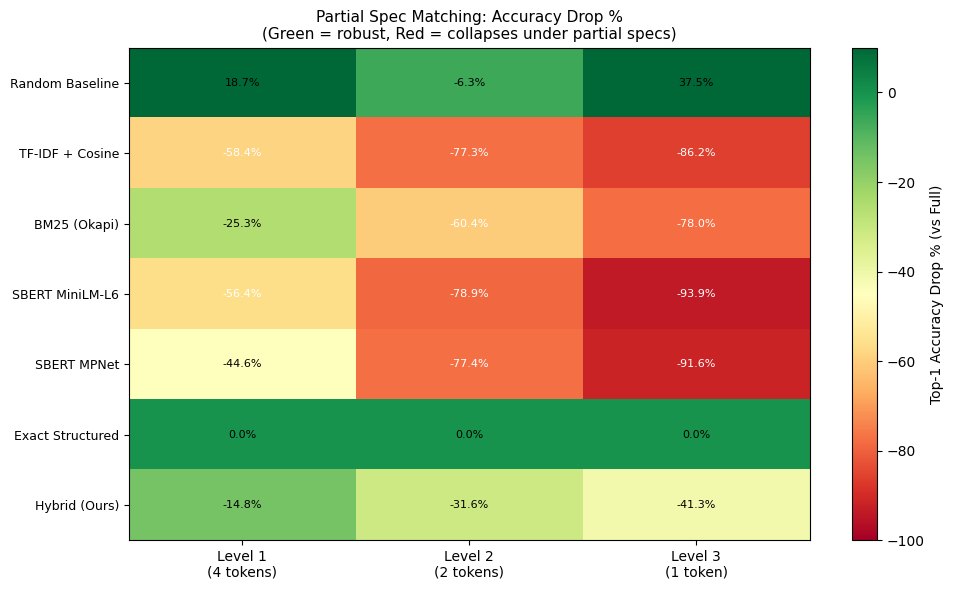

✅ Saved exp6_drop_heatmap.png


In [14]:
# CELL 12 — VISUALISATION 2: DROP % HEATMAP
fig, ax = plt.subplots(figsize=(10, 6))
heat_cols = ['Level1_Drop%','Level2_Drop%','Level3_Drop%']
heat_data = ir_df[heat_cols].values
models_list = ir_df['Model'].tolist()

im = ax.imshow(heat_data, cmap='RdYlGn', aspect='auto', vmin=-100, vmax=10)
ax.set_xticks(range(3))
ax.set_xticklabels(['Level 1\n(4 tokens)', 'Level 2\n(2 tokens)', 'Level 3\n(1 token)'], fontsize=10)
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels([m.replace(' (sem-only)','') for m in models_list], fontsize=9)
for r in range(len(models_list)):
    for c in range(3):
        val = heat_data[r, c]
        ax.text(c, r, f'{val:.1f}%', ha='center', va='center',
                fontsize=8, color='white' if val < -55 else 'black')
plt.colorbar(im, ax=ax, label='Top-1 Accuracy Drop % (vs Full)')
ax.set_title('Partial Spec Matching: Accuracy Drop %\n(Green = robust, Red = collapses under partial specs)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp6_drop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp6_drop_heatmap.png')

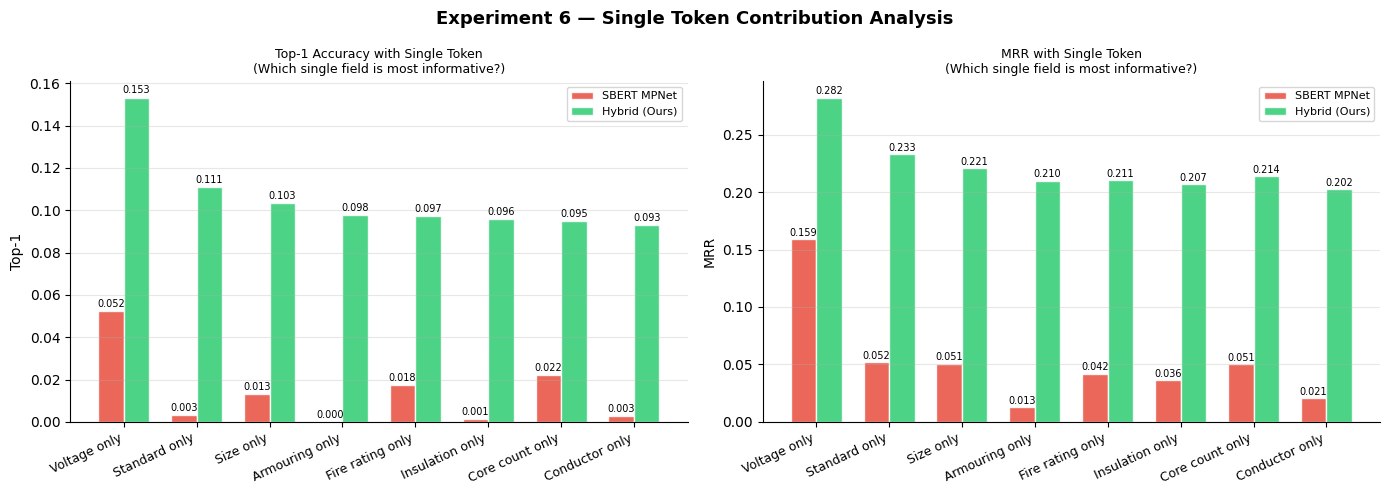

✅ Saved exp6_single_token.png


In [15]:
# CELL 13 — VISUALISATION 3: SINGLE TOKEN CONTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
token_names = st_df['Token Type'].tolist()
x = np.arange(len(token_names))
w = 0.35

for ax, (col, title) in zip(axes, [
    ('Top-1', 'Top-1 Accuracy with Single Token'),
    ('MRR',   'MRR with Single Token'),
]):
    ax.bar(x-w/2, st_df[f'SBERT {col}'].values, w, color='#e74c3c',
           alpha=0.85, edgecolor='white', label='SBERT MPNet')
    ax.bar(x+w/2, st_df[f'Hybrid {col}'].values, w, color='#2ecc71',
           alpha=0.85, edgecolor='white', label='Hybrid (Ours)')
    for i, (a,b) in enumerate(zip(st_df[f'SBERT {col}'], st_df[f'Hybrid {col}'])):
        ax.text(i-w/2, a+0.001, f'{a:.3f}', ha='center', va='bottom', fontsize=7)
        ax.text(i+w/2, b+0.001, f'{b:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(token_names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(col)
    ax.set_title(f'{title}\n(Which single field is most informative?)', fontsize=9)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 6 — Single Token Contribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp6_single_token.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp6_single_token.png')

In [16]:
# CELL 14 — CONCRETE EXAMPLES: SBERT FAILS, HYBRID SUCCEEDS
print('=== Partial Spec Matching: SBERT Fails, Hybrid Holds ===\n')

def top1_sku(grp_dict, rfp_id, sk):
    g = grp_dict[rfp_id]
    return g['sku_id'][np.lexsort((g['sku_id'], -g[sk]))[0]]

for level_name in ['Level1', 'Level2', 'Level3']:
    wins = [r for r in gt_lookup
            if top1_sku(groups['Full'],r,'semantic') == gt_lookup[r]
            and top1_sku(groups[level_name],r,'semantic') != gt_lookup[r]
            and top1_sku(groups[level_name],r,'hybrid')  == gt_lookup[r]]
    print(f'--- {level_name}: SBERT loses GT, Hybrid keeps GT: {len(wins)} RFPs ---')
    src = {'Level1':df_level1,'Level2':df_level2,'Level3':df_level3}[level_name]
    for rfp_id in wins[:4]:
        idx = df_clean[df_clean['rfp_id']==rfp_id].index[0]
        print(f'  RFP: {rfp_id}  GT: {gt_lookup[rfp_id]}')
        print(f'  FULL  : {df_clean.loc[idx,"spec_text_raw"]}')
        print(f'  PARTIAL: {src.loc[idx,"spec_text_raw"]}')
        print(f'  SBERT full={top1_sku(groups["Full"],rfp_id,"semantic")}  partial={top1_sku(groups[level_name],rfp_id,"semantic")}  X')
        print(f'  Hybrid full={top1_sku(groups["Full"],rfp_id,"hybrid")}  partial={top1_sku(groups[level_name],rfp_id,"hybrid")}  OK')
        print()
    print()

=== Partial Spec Matching: SBERT Fails, Hybrid Holds ===

--- Level1: SBERT loses GT, Hybrid keeps GT: 135 RFPs ---
  RFP: RFP_0027  GT: SKU_176
  FULL  : FRLS 400kV 1C 500 sqmm Al XLPE armoured cable as per IEC 62067
  PARTIAL: FRLS XLPE armoured cable as per IEC 62067
  SBERT full=SKU_176  partial=SKU_219  X
  Hybrid full=SKU_176  partial=SKU_176  OK

  RFP: RFP_0045  GT: SKU_254
  FULL  : ZH 6.6kV 1C 95 sqmm Al EPR armoured cable as per IS 7098-1
  PARTIAL: 6.6kV 1C EPR cable as per IS 7098-1
  SBERT full=SKU_254  partial=SKU_255  X
  Hybrid full=SKU_254  partial=SKU_254  OK

  RFP: RFP_0131  GT: SKU_137
  FULL  : Fire Survival 1.1kV 4C 95 sqmm Cu Mineral (MI) armoured cable as per IS 17048
  PARTIAL: 4C 95 sqmm Mineral (MI) armoured cable as per IS 17048
  SBERT full=SKU_137  partial=SKU_244  X
  Hybrid full=SKU_137  partial=SKU_137  OK

  RFP: RFP_0334  GT: SKU_176
  FULL  : FR 66kV 1C 500 sqmm Cu XLPE armoured cable as per IEC 60840
  PARTIAL: 1C 500 sqmm Cu cable as per IEC 6084

In [17]:
# CELL 15 — FINAL SUMMARY (PAPER-READY)
print('\n' + '='*115)
print('  EXPERIMENT 6 — PARTIAL SPECIFICATION MATCHING: COMPLETE RESULTS SUMMARY')
print('='*115)

print('\n-- Section A: IR Metrics Across All Completeness Levels --')
print(ir_df[['Model','Full_Top1','Level1_Top1','Level1_Drop%',
              'Level2_Top1','Level2_Drop%','Level3_Top1','Level3_Drop%',
              'Full_MRR','Level1_MRR','Level2_MRR','Level3_MRR']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n-- Section B: Single Token Contribution (ranked by Hybrid Top-1) --')
print(st_df.to_markdown(index=False, floatfmt='.4f'))

h = ir_df[ir_df['Model']=='Hybrid (Ours)'].iloc[0]
s = ir_df[ir_df['Model']=='SBERT MPNet (sem-only)'].iloc[0]
def ret(row, level): return row[f'{level}_Top1']/row['Full_Top1']*100 if row['Full_Top1']>0 else 0

print(f'\n-- Key Findings --')
for level in ['Level1','Level2','Level3']:
    h_ret = ret(h, level); s_ret = ret(s, level)
    lname = {'Level1':'4 tokens','Level2':'2 tokens','Level3':'1 token'}[level]
    ratio = h_ret/s_ret if s_ret > 0 else float('inf')
    print(f'  [{lname}]: Hybrid={h_ret:.1f}%  SBERT={s_ret:.1f}%  -> Hybrid {ratio:.2f}x more robust')

best_st = st_df.iloc[0]
print(f'\n  Most informative single token for Hybrid: {best_st["Token Type"]}'
      f'  (Top-1={best_st["Hybrid Top-1"]:.4f})')
print(f'  Most informative single token for SBERT:  {st_df.sort_values("SBERT Top-1",ascending=False).iloc[0]["Token Type"]}')

print(f'\n  Cross-experiment summary:')
print(f'  Exp1 Wrong values:    SBERT 44.0%  Hybrid 85.6%  1.95x')
print(f'  Exp2 Unit notation:   SBERT 76.6%  Hybrid 94.8%  1.24x')
print(f'  Exp3 Missing (1-4fld):SBERT 65.1%  Hybrid 89.2%  1.37x')
print(f'  Exp4 Noise in-domain: SBERT 51.3%  Hybrid 88.6%  1.73x')
print(f'  Exp5 Long doc:        SBERT  8.1%  Hybrid 65.7%  8.12x')
print(f'  Exp6 Partial (1 tok): SBERT {ret(s,"Level3"):.1f}%  Hybrid {ret(h,"Level3"):.1f}%')


  EXPERIMENT 6 — PARTIAL SPECIFICATION MATCHING: COMPLETE RESULTS SUMMARY

-- Section A: IR Metrics Across All Completeness Levels --
| Model                  |   Full_Top1 |   Level1_Top1 |   Level1_Drop% |   Level2_Top1 |   Level2_Drop% |   Level3_Top1 |   Level3_Drop% |   Full_MRR |   Level1_MRR |   Level2_MRR |   Level3_MRR |
|:-----------------------|------------:|--------------:|---------------:|--------------:|---------------:|--------------:|---------------:|-----------:|-------------:|-------------:|-------------:|
| Random Baseline        |      0.0046 |        0.0054 |        18.7500 |        0.0043 |        -6.2500 |        0.0063 |        37.5000 |     0.0298 |       0.0299 |       0.0293 |       0.0296 |
| TF-IDF + Cosine        |      0.1343 |        0.0559 |       -58.4043 |        0.0304 |       -77.3404 |        0.0186 |       -86.1702 |     0.2460 |       0.1300 |       0.0844 |       0.0632 |
| BM25 (Okapi)           |      0.0559 |        0.0417 |       -25.3197 |

In [18]:
# CELL 16 — EXPORT
ir_df.to_csv(f'{EXP_DIR}/exp6_completeness_metrics.csv', index=False)
st_df.to_csv(f'{EXP_DIR}/exp6_single_token_analysis.csv', index=False)

# Save partial spec texts for inspection
pd.DataFrame({'rfp_id': df_clean['rfp_id'],
              'full_spec': df_clean['spec_text_raw'],
              'level1_spec': df_level1['spec_text_raw'],
              'level2_spec': df_level2['spec_text_raw'],
              'level3_spec': df_level3['spec_text_raw']})\
  .to_csv(f'{EXP_DIR}/exp6_partial_specs_all_levels.csv', index=False)

print('✅ Saved:')
for fn in sorted(os.listdir(EXP_DIR)):
    size = os.path.getsize(f'{EXP_DIR}/{fn}') / 1024
    print(f'   {EXP_DIR}/{fn}  ({size:.0f} KB)')

✅ Saved:
   exp6_partial_spec/exp6_completeness_metrics.csv  (3 KB)
   exp6_partial_spec/exp6_degradation_curves.png  (273 KB)
   exp6_partial_spec/exp6_drop_heatmap.png  (90 KB)
   exp6_partial_spec/exp6_partial_specs_all_levels.csv  (948 KB)
   exp6_partial_spec/exp6_single_token.png  (123 KB)
   exp6_partial_spec/exp6_single_token_analysis.csv  (1 KB)
